In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

100%|██████████| 182M/182M [00:21<00:00, 8.41MB/s] 


100%|██████████| 64.3M/64.3M [00:14<00:00, 4.38MB/s]


Epoch [1/100], Loss: 1.1895, Accuracy: 61.53%
Epoch [2/100], Loss: 0.8560, Accuracy: 73.60%
Epoch [3/100], Loss: 0.7583, Accuracy: 76.72%
Epoch [4/100], Loss: 0.7047, Accuracy: 78.45%
Epoch [5/100], Loss: 0.6651, Accuracy: 79.74%
Epoch [6/100], Loss: 0.6230, Accuracy: 80.91%
Epoch [7/100], Loss: 0.5969, Accuracy: 81.55%
Epoch [8/100], Loss: 0.5717, Accuracy: 82.31%
Epoch [9/100], Loss: 0.5573, Accuracy: 82.96%
Epoch [10/100], Loss: 0.5372, Accuracy: 83.51%
Epoch [11/100], Loss: 0.5119, Accuracy: 84.16%
Epoch [12/100], Loss: 0.5106, Accuracy: 84.37%
Epoch [13/100], Loss: 0.4892, Accuracy: 84.82%
Epoch [14/100], Loss: 0.4814, Accuracy: 85.21%
Epoch [15/100], Loss: 0.4662, Accuracy: 85.73%
Epoch [16/100], Loss: 0.4638, Accuracy: 85.73%
Epoch [17/100], Loss: 0.4409, Accuracy: 86.40%
Epoch [18/100], Loss: 0.4504, Accuracy: 86.23%
Epoch [19/100], Loss: 0.4350, Accuracy: 86.56%
Epoch [20/100], Loss: 0.4275, Accuracy: 86.72%
Epoch [21/100], Loss: 0.4228, Accuracy: 86.92%
Epoch [22/100], Loss: 

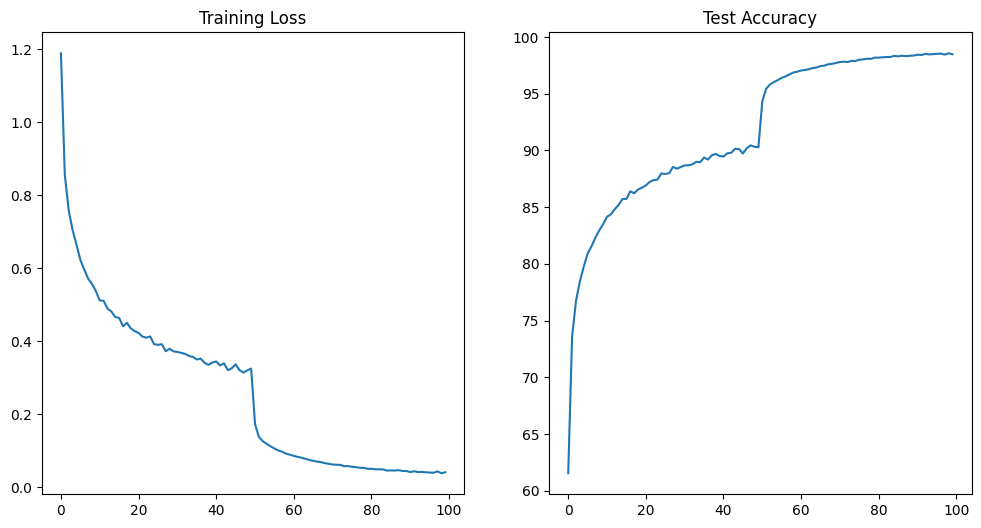

Test Accuracy: 82.96%


In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import SVHN
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define Convolution Tables (CT) model (a simplified version using lookup tables)
class CTModel(nn.Module):
    def __init__(self):
        super(CTModel, self).__init__()
        # Simulating convolution with lookup table for simplicity
        self.fc1 = nn.Linear(3 * 32 * 32, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)  # 10 classes for SVHN

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Load SVHN dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728], std=[0.1980, 0.2010, 0.1970])
])

trainset = SVHN(root='./data', split='train', download=True, transform=transform)
testset = SVHN(root='./data', split='test', download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=1000, shuffle=False)

# Initialize model, optimizer, and criterion
model = CTModel().cuda()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

# Training function
def train_model(num_epochs=100):
    train_losses = []
    test_accuracies = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        for inputs, labels in trainloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        scheduler.step()

        train_losses.append(running_loss / len(trainloader))
        test_accuracy = 100 * correct / total
        test_accuracies.append(test_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}, Accuracy: {test_accuracy:.2f}%")

    return train_losses, test_accuracies

# Evaluation function
def evaluate_model():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Plotting function
def plot_metrics(train_losses, test_accuracies):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(test_accuracies)
    plt.title('Test Accuracy')
    
    plt.show()

# Train and evaluate the model
train_losses, test_accuracies = train_model(num_epochs=100)
plot_metrics(train_losses, test_accuracies)
evaluate_model()
